In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

In [3]:
# 1. 데이터 로드
train_df = pd.read_csv('dataset/train_titanic.csv')
test_df = pd.read_csv('dataset/test_titanic.csv')

In [4]:
# 1.1 전처리 전 데이터 확인
print('=== 전처리 전 데이터 (train_df) ===')
print(train_df.head())
print('\n === 데이터 기본 정보 ===')
print(train_df.info())
print('\n === 결측치 확인 ===')
print(train_df.isnull().sum())

=== 전처리 전 데이터 (train_df) ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

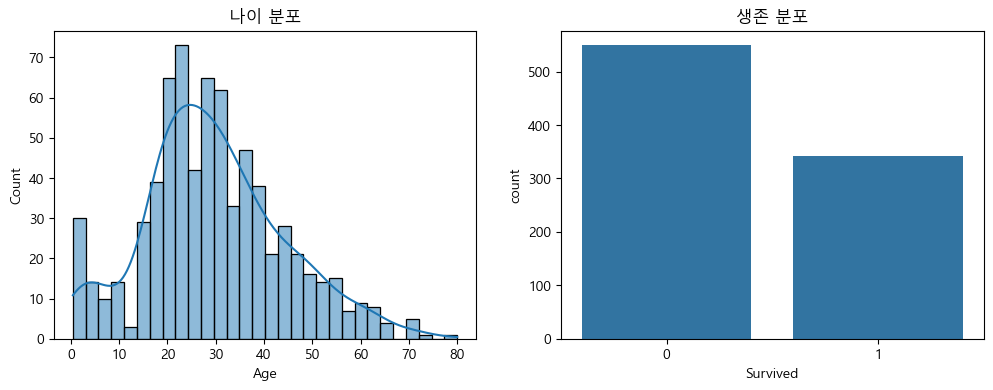

In [5]:
# 주요 특성 분포 시각화
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(train_df['Age'].dropna(), bins=30, kde=True)
plt.title('나이 분포')
plt.subplot(1,2,2)
sns.countplot(x="Survived", data=train_df)
plt.title('생존 분포')
plt.show()

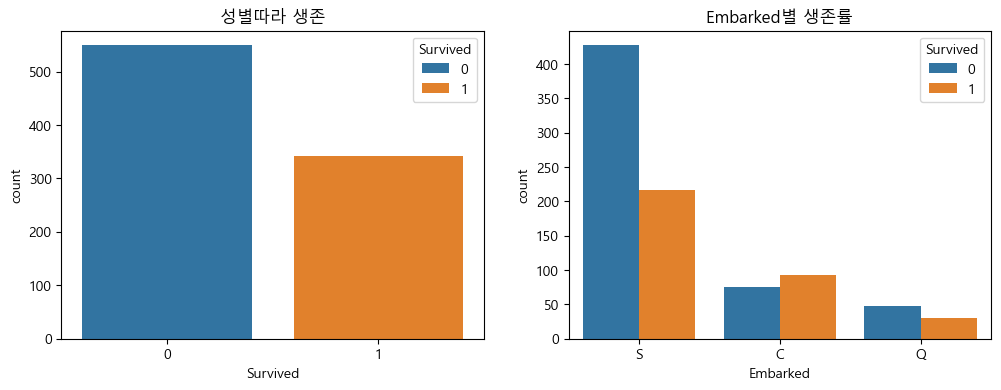

In [6]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(x="Survived", hue='Survived', data=train_df)
plt.title('성별따라 생존')
plt.subplot(1,2,2)
sns.countplot(x='Embarked', hue='Survived', data=train_df)
plt.title('Embarked별 생존률')
plt.show()


In [7]:
# 2. 데이터 전처리
# 결측값 처리
train_df = train_df.assign(Age=train_df['Age'].fillna(train_df['Age'].median()))
test_df = test_df.assign(Age=test_df['Age'].fillna(test_df['Age'].median()))
train_df = train_df.assign(Embarked=train_df['Embarked'].fillna(train_df['Embarked'].mode()[0]))
test_df = test_df.assign(Fare=test_df['Fare'].fillna(test_df['Fare'].median()))

In [8]:
# 특징 선택
features = ['Pclass', 'Sex', 'Age','SibSp','Parch','Fare','Embarked']
X_train = train_df[features]
y_train = train_df['Survived']
X_test = test_df[features]

In [9]:
# 3. 원핫 인코딩
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_features_train = ohe.fit_transform(X_train[['Sex','Embarked']])
cat_feature_names = ohe.get_feature_names_out(['Sex','Embarked'])
cat_features_test = ohe.transform(X_test[['Sex','Embarked']])

In [10]:
# 연속형 데이터
num_features_train = X_train[['Pclass','Age','SibSp','Parch','Fare']]
num_features_test = X_test[['Pclass','Age','SibSp','Parch','Fare']]
scaler = StandardScaler()
num_features_train_scaled = scaler.fit_transform(num_features_train)
num_features_test_scaled = scaler.transform(num_features_test)

In [11]:
# 데이터 결합
X_train_combined = np.hstack([num_features_train_scaled, cat_features_train])
X_test_combined = np.hstack([num_features_test_scaled, cat_features_test])

In [12]:
# 3.1 원핫 인코딩 후 데이터 확인
X_train_combined_df = pd.DataFrame(X_train_combined, columns=list(num_features_train.columns) + list(cat_feature_names))
print('\n === 원핫 인코딩 후 데이터 (train) ===')
print(X_train_combined_df.head())
print('\n === 원핫 인코딩 후 특성 수 ===')
print(f'특성 수 : {X_train_combined.shape[1]}')



 === 원핫 인코딩 후 데이터 (train) ===
     Pclass       Age     SibSp     Parch      Fare  Sex_female  Sex_male  \
0  0.827377 -0.565736  0.432793 -0.473674 -0.502445         0.0       1.0   
1 -1.566107  0.663861  0.432793 -0.473674  0.786845         1.0       0.0   
2  0.827377 -0.258337 -0.474545 -0.473674 -0.488854         1.0       0.0   
3 -1.566107  0.433312  0.432793 -0.473674  0.420730         1.0       0.0   
4  0.827377  0.433312 -0.474545 -0.473674 -0.486337         0.0       1.0   

   Embarked_C  Embarked_Q  Embarked_S  
0         0.0         0.0         1.0  
1         1.0         0.0         0.0  
2         0.0         0.0         1.0  
3         0.0         0.0         1.0  
4         0.0         0.0         1.0  

 === 원핫 인코딩 후 특성 수 ===
특성 수 : 10


In [13]:
# 4. PCA 적용
pca = PCA(n_components=0.95) # 95% 분산 유지
X_train_pca = pca.fit_transform(X_train_combined)
X_test_pca = pca.transform(X_test_combined)

In [14]:
# 4.1 PCA 적용 후 데이터 확인
print('\n === PCA 적용 후 데이터 (train) ===')
print(pd.DataFrame(X_train_pca).head())
print('\n === PCA 후 특성 수 ===')
print(f'특성 수 : {X_train_pca.shape[1]}')
print('\n === PCA 설명된 분산 비율 ===')
print(pca.explained_variance_ratio_)


 === PCA 적용 후 데이터 (train) ===
          0         1         2         3         4         5         6
0  1.189309  0.192409 -0.110413  0.659347 -0.288647 -0.084718  0.192395
1 -1.928325 -0.283466 -0.261757  0.478090  1.101178  0.310490 -0.695613
2  0.952821 -0.283762 -0.244249 -0.375087  0.717514  0.471797  0.655214
3 -1.477304 -0.221825 -0.097151  0.492243  1.142331 -0.463277  0.425057
4  0.884103 -0.794282  0.416630  0.052776 -0.452524  0.185091  0.287513

 === PCA 후 특성 수 ===
특성 수 : 7

 === PCA 설명된 분산 비율 ===
[0.29349319 0.28200411 0.12503667 0.1013726  0.06904592 0.06537826
 0.04703816]


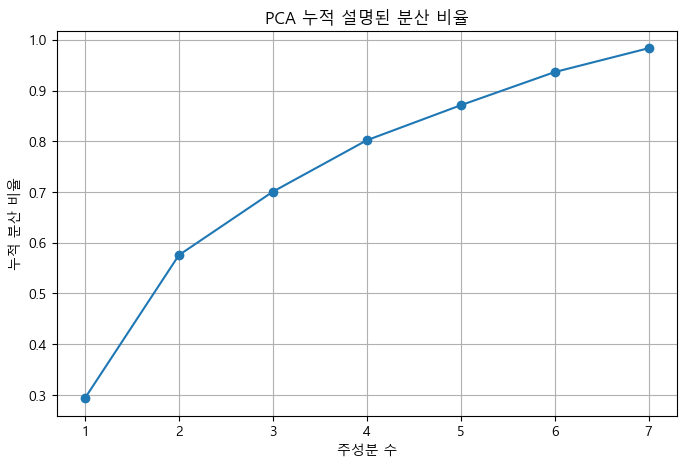

In [15]:
# PCA 설명된 분산 비율 시각화
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+ 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('PCA 누적 설명된 분산 비율')
plt.xlabel('주성분 수')
plt.ylabel('누적 분산 비율')
plt.grid(True)
plt.show()

In [16]:
# 5. MLP 모델 구성
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0,3),
    Dense(16, activation='relu'),
    Dropout(0,3),
    Dense(1, activation='sigmoid')
])

d:\python_sim\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
# 6. 학습
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train_pca, y_train, epochs=50, batch_size=32,
                    validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4031 - loss: 0.7604 - val_accuracy: 0.4637 - val_loss: 0.6981
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5758 - loss: 0.6683 - val_accuracy: 0.7374 - val_loss: 0.6348
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7303 - loss: 0.6232 - val_accuracy: 0.7989 - val_loss: 0.5909
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7725 - loss: 0.5905 - val_accuracy: 0.8156 - val_loss: 0.5581
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7865 - loss: 0.5611 - val_accuracy: 0.8156 - val_loss: 0.5236
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7921 - loss: 0.5327 - val_accuracy: 0.8156 - val_loss: 0.4877
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7978 - loss: 0.5053 - val_accuracy: 0.8156 - val_loss: 0.4545
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8006 - loss: 0.4800 - val_accuracy: 0.8212 - val_loss

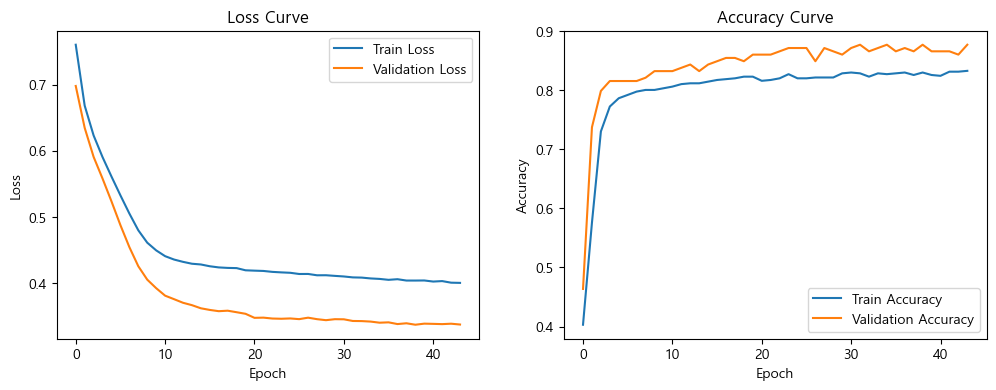

In [19]:
# 7. 학습 결과 시각화
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [20]:
# 8. 테스트 데이터 예측
y_pred = (model.predict(X_test_pca) > 0.5).astype(int).flatten() # sigmoid 출력이 0.5이상이면 생존 미만이면 사망

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [21]:
# 예측 결과 저장
submission = pd.DataFrame({
    'PassengerId' : test_df['PassengerId'],
    'Survived' : y_pred
})
submission.to_csv('./dataset/sumbission.csv', index=False)
print('\n === 예측 결과 상위 5개 ===')
print(submission.head())


 === 예측 결과 상위 5개 ===
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


In [28]:
# 사전 라이브러리 설치(XAI용, XAI: 설명가능한 AI, Explainable AI) : pip install shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.impute import SimpleImputer    # 결측치를 처리하는데 사용
from sklearn.preprocessing import LabelEncoder    # 범주형 데이터를 숫자형 데이터로 변환하는 데 사용
import shap  # feature importance와 유사 (LSTM에 사용)

d:\python_sim\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
# 1. 데이터 로드 및 전처리
train_df = pd.read_csv('dataset/train_titanic.csv')
test_df = pd.read_csv('dataset/test_titanic.csv')

In [30]:
# 데이터 확인
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
# 결측치 확인
print('Train 데이터 결측치 확인 :')
print(train_df.isnull().sum())
print('\nTest 데이터 결측치 확인 :')
print(test_df.isnull().sum())

Train 데이터 결측치 확인 :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          688
Embarked         2
dtype: int64

Test 데이터 결측치 확인 :
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [33]:
# 불필요한 컬럼 제거 (원핫 인코딩 없이도 잘 작동하도록)
train_df = train_df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
test_df = test_df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

In [34]:
# Label 인코딩 (성별 컬럼)
le = LabelEncoder() # 범주형 문자열을 숫자형으로 변화
train_df['Sex'] = le.fit_transform(train_df['Sex'])
test_df['Sex'] = le.transform(test_df['Sex'])
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [36]:
# Embarked 컬럼 처리 (최빈값으로 채우기)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [37]:
# 라벨 인코딩 (Embarked 컬럼)
le_embakred = LabelEncoder()
train_df['Embarked'] = le_embakred.fit_transform(train_df['Embarked'])
test_df['Embarked'] = le_embakred.transform(test_df['Embarked']) # train 데이터 기준으로 transform

In [40]:
# Age 컬럼 결측치 처리 (평균으로 채우기)
imputer = SimpleImputer(strategy='mean')
train_df['Age'] = imputer.fit_transform(train_df[['Age']])
test_df['Age'] = imputer.transform(test_df[['Age']])

# Fare 컬럼 결측치 처리 (평균으로 채우기)
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].mean())# test 데이터에만 Fare 결측치 존재

In [41]:
# 전처리 후 데이터 확인
print('전처리 후 데이터 형태 :')
print('train 데이터 :', train_df.shape)
print('test 데이터 :', test_df.shape)

전처리 후 데이터 형태 :
train 데이터 : (891, 8)
test 데이터 : (418, 7)


In [42]:
# 데이터 컬럼 확인
print('\n Train 데이터 컬럼 :', train_df.columns.tolist())
print('Test 데이터 컬럼 :', test_df.columns.tolist())


 Train 데이터 컬럼 : ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Test 데이터 컬럼 : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [43]:
# 스케일링 (MinMaxScaler)
scaler = MinMaxScaler()
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

In [44]:
# 피처 수 확인
n_features = X.shape[1]
print(f'피처 수 : {n_features}')

피처 수 : 7


In [45]:
X = scaler.fit_transform(X)
test_data = scaler.transform(test_df)

In [46]:
# 특성 이름 저장 (SHAP 시각화에 사용)
feature_names = train_df.drop('Survived', axis=1).columns.tolist()

In [48]:
# train, validation set 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
# 데이터 형태 확인
print(f'X_train 형태 (reshape 전) : {X_train.shape}')
print(f'X_val 형태 (reshape 전) : {X_val.shape}')
print(f'test_data 형태 (reshape 전) : {test_data.shape}')

X_train 형태 (reshape 전) : (712, 7)
X_val 형태 (reshape 전) : (179, 7)
test_data 형태 (reshape 전) : (418, 7)


In [51]:
# LSTM 입력을 위한 reshape( samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], 1, n_features) # 범주형 데이터에서는 일반적으로 timesteps = 1
X_val = X_val.reshape(X_val.shape[0], 1 , n_features)
test_data = test_data.reshape(test_data.shape[0], 1, n_features)

In [52]:
# reshape 후 형태 확인
print(f'X_train 형태 (reshape 후) : {X_train.shape}')
print(f'X_val 형태 (reshape 후) : {X_val.shape}')
print(f'test_data 형태 (reshape 후) : {test_data.shape}')

X_train 형태 (reshape 후) : (712, 1, 7)
X_val 형태 (reshape 후) : (179, 1, 7)
test_data 형태 (reshape 후) : (418, 1, 7)


In [53]:
# 2. LSTM 모델 구축
model = Sequential()
model.add(LSTM(64, input_shape=(1, n_features), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid')) # 생존여부에 대한 이진 분류(1,0) 이므로 sigmoid 사용

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

d:\python_sim\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
# 모델 구조 확인
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Early Stopping - verbose=1로 설정하여 진행상황 확인
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # 10번의 에폭동안 개선이 없으면 학습 중단
    restore_best_weights=True, # 가장 좋은 성능을 보였던 모델의 가중치를 복원
    verbose=1 # 중단시 메시지 출력
)

In [57]:
# 3. 모델 훈련 - verbose=1 로 설정하여 진행상황 확인
epochs= 100
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data = (X_val, y_val),
    callbacks=[early_stopping],
    verbose=1 # 훈련 진행상황 출력
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.6180 - loss: 0.6823 - val_accuracy: 0.5866 - val_loss: 0.6726
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6236 - loss: 0.6546 - val_accuracy: 0.5866 - val_loss: 0.6427
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6236 - loss: 0.6226 - val_accuracy: 0.5866 - val_loss: 0.6171
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6250 - loss: 0.5924 - val_accuracy: 0.5922 - val_loss: 0.5937
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6404 - loss: 0.5714 - val_accuracy: 0.6704 - val_loss: 0.5691
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6952 - loss: 0.5526 - val_accuracy: 0.7151 - val_loss: 0.5451
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7669 - loss: 0.5348 - val_accuracy: 0.7486 - val_loss: 0.5262
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7823 - loss: 0.5215 - val_accuracy: 0.7709 - 

In [58]:
# 학습이 몇 번째 에폭 에서 멈췄는지 확인
actual_epochs = len(history.history['loss'])
print(f'학습이 {actual_epochs}번째 에폭에서 완료되었습니다')

학습이 75번째 에폭에서 완료되었습니다


In [59]:
# 4. 예측 및 평가
# Validation set 평가
y_pred_val_proba = model.predict(X_val, verbose=0)
 
y_pred_val = (y_pred_val_proba > 0.5).astype(int) # 0.5를 기준으로 분류 True는 1로 False는 0으로

In [60]:
# 테스트 데이터 예측
y_pred_proba = model.predict(test_data, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

In [61]:
# ROC 커브 및 AUC 계산 
fpr, tpr, thresholds = roc_curve(y_val, y_pred_val_proba)
roc_auc = auc(fpr, tpr)

In [62]:
# 혼동 행렬
cm = confusion_matrix(y_val, y_pred_val)
print('Confusion Matrix (Validation Set) : \n', cm)

Confusion Matrix (Validation Set) : 
 [[95 10]
 [25 49]]


In [63]:
# Classification Report 
print('\n Classification Report : \n', classification_report(y_val, y_pred_val))


 Classification Report : 
               precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.66      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



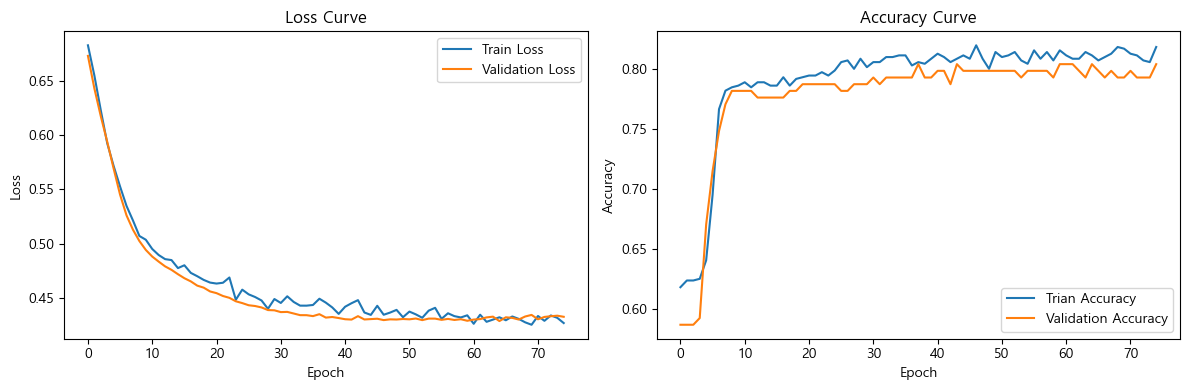

In [65]:
# 5. 결과 시각화 및 통계 분석

# 학습 곡선 시각화 (loss, accuracy)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Trian Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

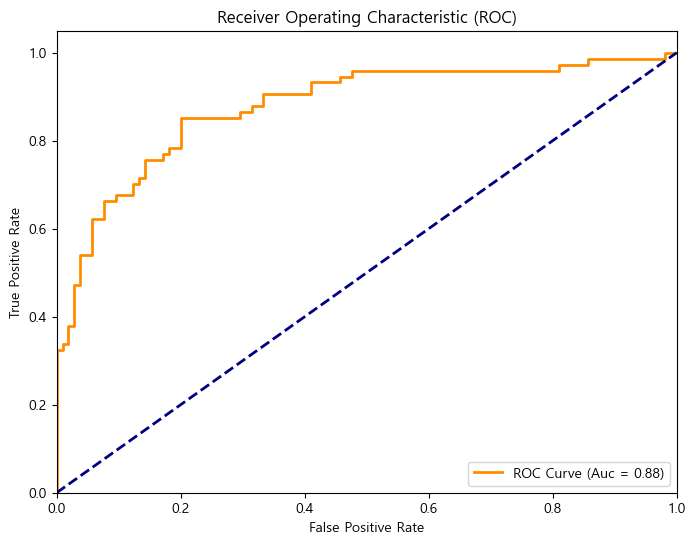

In [66]:
# ROC Curve 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (Auc = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


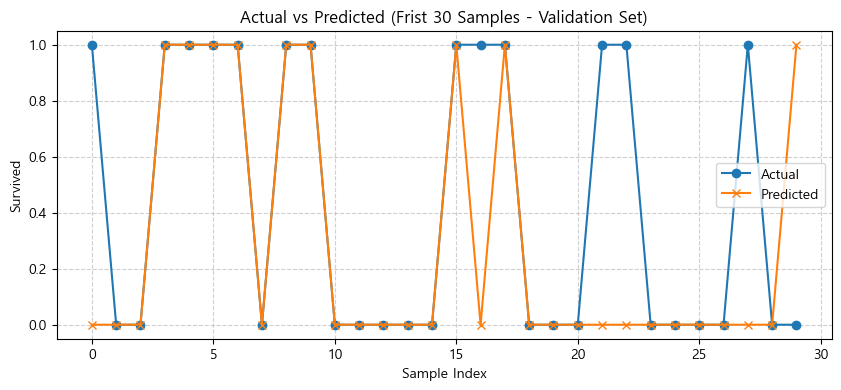

In [67]:
# 실제 값 vs 예측값 시각화 
plt.figure(figsize=(10,4))
plt.plot(y_val[:30].values, label='Actual', marker='o')
plt.plot(y_pred_val[:30].flatten(), label='Predicted', marker='x')
plt.title('Actual vs Predicted (Frist 30 Samples - Validation Set)')
plt.xlabel('Sample Index')
plt.ylabel('Survived')
plt.legend()
plt.grid(True, linestyle= '--', alpha=0.6) # 그리드 추가
plt.show()

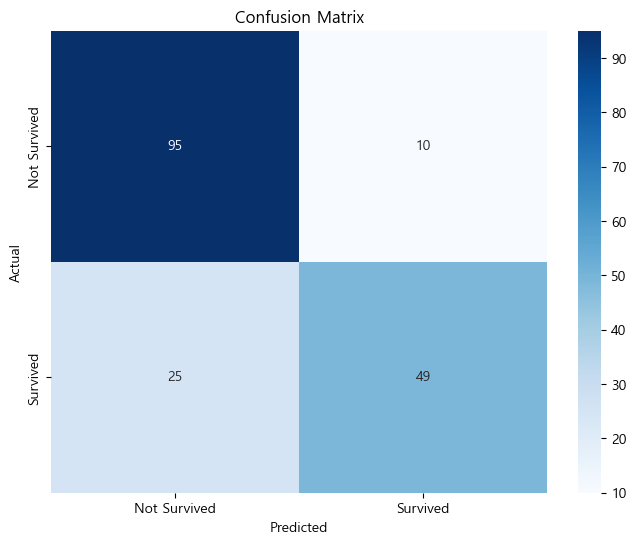

In [68]:
# 혼동행렬 시각화
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [69]:
# 6. 데이터셋 로드
# test_titanic.csv에서 직접 PassengerId 가져오기
original_test_df = pd.read_csv('dataset/test_titanic.csv')
passenger_ids = original_test_df['PassengerId']

In [70]:
# 예측 결과와 PassengerId를 합쳐 새로운 Data Frame생성ㄷ
forecast_results = pd.DataFrame({
    'PassengerId' : passenger_ids,
    'Survived' : y_pred.flatten() # flatten()으로 1차원 배열로 변환
})

In [71]:
# 결과 확인
print('예측 결과 (처음 5개 샘플) : ')
print(forecast_results.head())

예측 결과 (처음 5개 샘플) : 
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


In [72]:
# 결과를 CSV 파일로 저장
forecast_results.to_csv('dataset/forecast_titanic.csv', index=False)
print('생존 예측 결과가 dataset/forecast_titanic.csv 파일로 저장되었습니다')

생존 예측 결과가 dataset/forecast_titanic.csv 파일로 저장되었습니다


In [73]:
# 모델 저장 
model.save('model/titanic_lstm_model.h5')
print('모델이 titanic_lstm_model.h5 저장됨')

모델이 titanic_lstm_model.h5 저장됨


In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [75]:
dataset = pd.read_csv('./dataset/KMeansData.csv')
dataset[:5]

,hour,score
0,7.33,73
1,3.71,55
2,3.43,55
3,3.06,89
4,3.33,79


In [76]:
X = dataset.iloc[:,:].values
X[:5]

array([[ 7.33, 73.  ],
       [ 3.71, 55.  ],
       [ 3.43, 55.  ],
       [ 3.06, 89.  ],
       [ 3.33, 79.  ]])

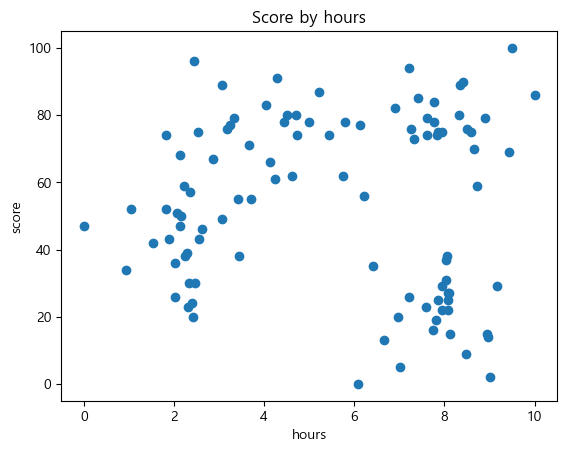

In [77]:
plt.scatter(X[:,0], X[:,-1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

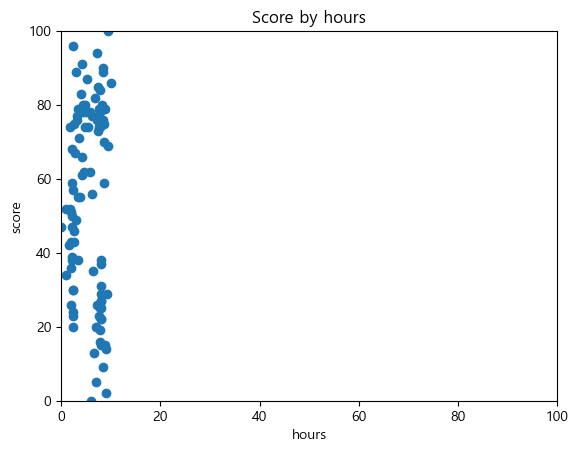

In [78]:
plt.scatter(X[:,0], X[:, 1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.xlim(0,100)
plt.ylabel('score')
plt.ylim(0,100)
plt.show()

In [79]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
X[:5]

array([[ 0.68729921,  0.73538376],
       [-0.66687438,  0.04198891],
       [-0.77161709,  0.04198891],
       [-0.9100271 ,  1.35173473],
       [-0.8090252 ,  0.96651537]])

d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


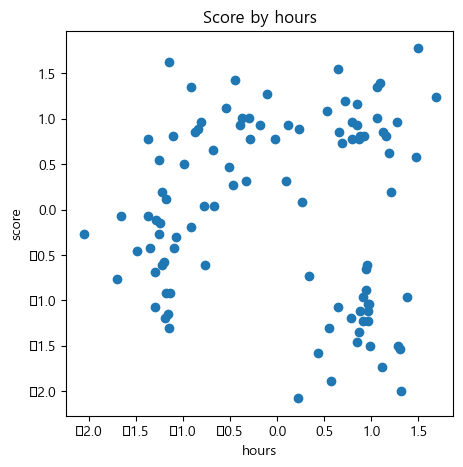

In [80]:
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1])
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

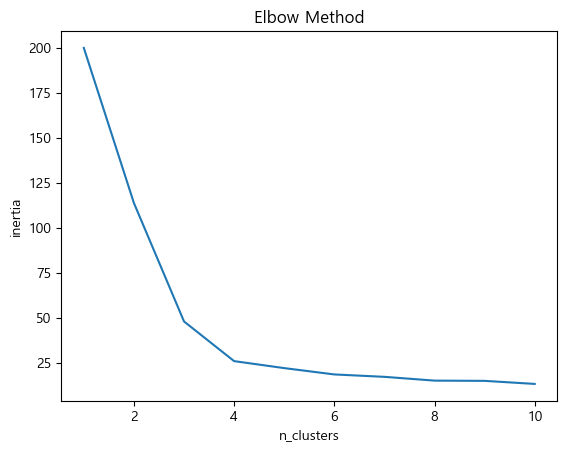

In [82]:
from sklearn.cluster import KMeans
inertia_list = []
for i in range(1, 11) :
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(X)
    inertia_list.append(kmeans.inertia_)
plt.plot(range(1,11), inertia_list)
plt.title('Elbow Method')
plt.xlabel('n_clusters')
plt.ylabel('inertia')
plt.show()

In [83]:
K=4
kmeans = KMeans(n_clusters=K, random_state=0)
y_kmeans = kmeans.fit_predict(X)

In [84]:
y_kmeans

array([1, 0, 3, 0, 0, 2, 2, 0, 1, 0, 0, 3, 2, 3, 3, 0, 2, 1, 3, 0, 2, 0,
       3, 2, 1, 1, 3, 3, 3, 3, 2, 2, 3, 0, 1, 1, 3, 0, 0, 0, 3, 2, 1, 3,
       3, 1, 2, 0, 2, 2, 1, 0, 2, 2, 0, 0, 0, 0, 3, 2, 2, 1, 1, 1, 1, 2,
       2, 0, 2, 1, 3, 1, 1, 1, 3, 3, 3, 3, 0, 1, 2, 1, 2, 2, 1, 0, 3, 2,
       1, 3, 0, 2, 0, 1, 3, 0, 1, 0, 2, 3], dtype=int32)

In [ ]:
centers = kmeans.cluster_centers_
centers

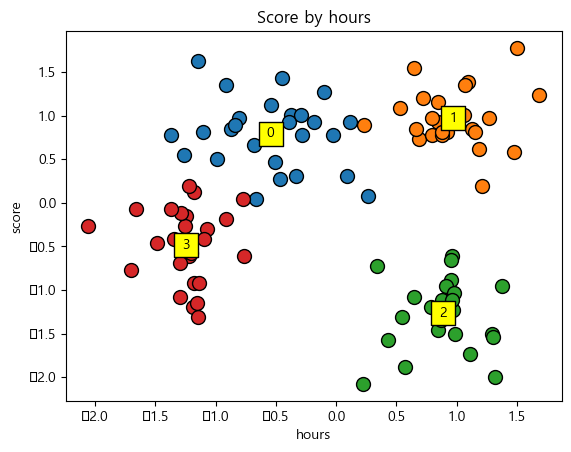

In [89]:
for cluster in range(K) :
    plt.scatter(X[y_kmeans == cluster, 0], X[y_kmeans == cluster, 1], s=100, edgecolor='black')
    plt.scatter(centers[cluster, 0], centers[cluster, 1], s=300, edgecolor='black',color='yellow',marker='s')
    plt.text(centers[cluster,0], centers[cluster, 1], cluster, va='center', ha='center')

plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

In [90]:
X_org = sc.inverse_transform(X)
X_org[:5]

array([[ 7.33, 73.  ],
       [ 3.71, 55.  ],
       [ 3.43, 55.  ],
       [ 3.06, 89.  ],
       [ 3.33, 79.  ]])

In [91]:
centers_org = sc.inverse_transform(centers)
centers_org

array([[ 4.04115385, 74.5       ],
       [ 8.08333333, 79.125     ],
       [ 7.8552    , 20.96      ],
       [ 2.1528    , 41.24      ]])

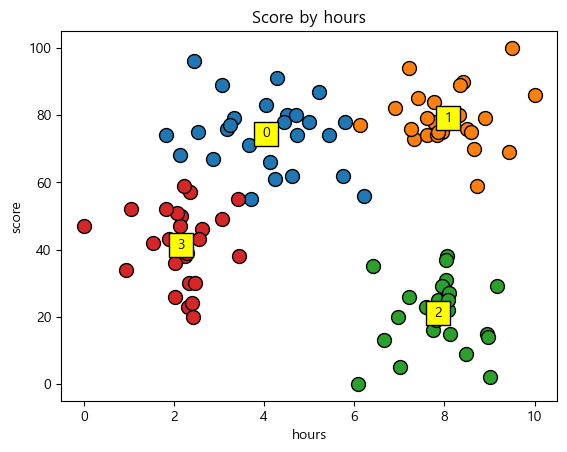

In [92]:
for cluster in range(K):
    plt.scatter(X_org[y_kmeans == cluster, 0], X_org[y_kmeans == cluster, 1], s=100, edgecolor='black')
    plt.scatter(centers_org[cluster, 0], centers_org[cluster, 1], s=300, edgecolor='black', color='yellow', marker='s')
    plt.text(centers_org[cluster, 0], centers_org[cluster, 1], cluster, va='center', ha='center')

plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

In [10]:
# 온도, 압력, 진동 센서 데이터를 활용한 비지도 학습 기반 이상 탐지 (오토인코더 기반)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # Matplotlib에서 3차원 플롯을 그릴 수 있도록 지원하는 도구

In [11]:
# 1. 데이터 불러오기
try :
    df_train = pd.read_csv('dataset/train_data.csv')
    df_test = pd.read_csv('dataset/test_data.csv')
except FileExistsError :
    print('지정된 경로에 파일이 존재하지 않습니다')
    exit()

In [12]:
# 2. 데이터 전처리
# 결측치 확인 및 처리
if df_train.isnull().sum().any() or df_test.isnull().sum().any() : # any() 결측치가 있으면 True, False로 반환함
    print('경고 : 결측치가 감지되었습니다. 평균값으로 채웁니다.')
    df_train.fillna(df_train.mean(), inplace=True)
    df_test.fillna(df_test.mean(), inplace=True)

# 피쳐 선택
X_train = df_train[['temperature', 'pressure','vibration']].values
X_test = df_test[['temperature','pressure','vibration']].values
y_test = df_test['label'].values #  0 = 정상, 1 = 불량

# 데이터 스케일링 (StandardScaler 사용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# 3. 오토 인코더 모델 정의
def build_autoencoder(input_dim) :
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        # 인코더
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        # 디코더
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(input_dim, activation=None)        
    ])
    return model

# 모델 생성 및 컴파일
autoencoder = build_autoencoder(input_dim=3)
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

In [20]:
# 4. 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [22]:
# 5. 모델 학습
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs = 100,
    batch_size = 32,
    shuffle = True,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose =1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.9236 - val_loss: 0.6369
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6304 - val_loss: 0.2462
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3526 - val_loss: 0.0873
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2512 - val_loss: 0.0455
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2070 - val_loss: 0.0384
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1885 - val_loss: 0.0294
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1863 - val_loss: 0.0294
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1770 - val_loss: 0.0273
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1552 - val_loss: 0.0329
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1569 - val_loss: 0.0267
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1563 - val_loss: 0.0258
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

In [24]:
# 6. 테스트셋에 대한 재구성 오차 계산
X_test_pred = autoencoder.predict(X_test_scaled, verbose=0)
mse = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

In [25]:
# 7. 임계값 설정 (기존 : 95% 백분위)
threshold_percentile = 95 # mse 값 중에서 하위 95% (정상), 상위 5% (불량)
threshold = np.percentile(mse, threshold_percentile)
print(f'Threshold ( {threshold_percentile}% percentile): {threshold:.4f}')

Threshold ( 95% percentile): 4.6255


In [26]:
# 8. 이상 탐지 결과 (기존 임계값 사용)
y_pred = (mse > threshold).astype(int)


 Classification Report (Threshold based on 95% percentile):
              precision    recall  f1-score   support

      Normal       0.70      1.00      0.83       100
     Anomaly       1.00      0.16      0.28        50

    accuracy                           0.72       150
   macro avg       0.85      0.58      0.55       150
weighted avg       0.80      0.72      0.64       150

 Confusion Matrix (Threshold based on 95% percentile):


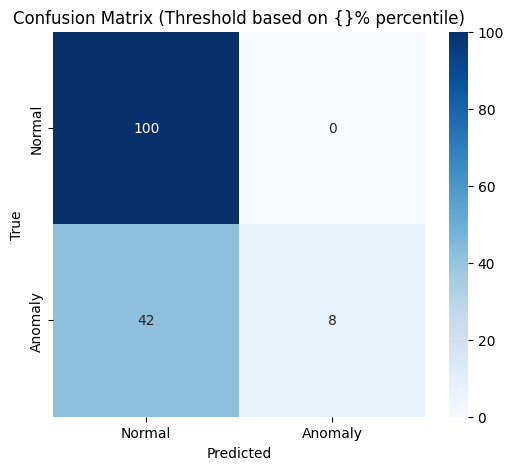

 ROC AUC Score (Threshold based on 95% percentile): 1.0000


In [27]:
# 9. 평가 (기존 임계값)
print("\n Classification Report (Threshold based on {}% percentile):".format(threshold_percentile))
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))  # Normal(정상), Anomaly(불량)

print(" Confusion Matrix (Threshold based on {}% percentile):".format(threshold_percentile))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Confusion Matrix (Threshold based on {}% percentile)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

roc_auc = roc_auc_score(y_test, mse)
print(f" ROC AUC Score (Threshold based on {threshold_percentile}% percentile): {roc_auc:.4f}")

In [28]:
# --- 최적 임계값 찾기 (F1 Score 기반) ---
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, mse)  #  이상 탐지 모델의 성능을 다양한 임계값에서 평가하기 위해 사용
f1_scores = 2 * recalls * precisions / (recalls + precisions + 1e-8)  # fl_scores 공식
best_threshold_idx = np.argmax(f1_scores) # f1_scores 배열에서 가장 큰 값의 인덱스(위치)를 찾아냄
best_threshold = thresholds_pr[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"\nBest Threshold (based on F1 score): {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")


Best Threshold (based on F1 score): 0.6517
Best F1 Score: 1.0000



 Classification Report (Optimized Threshold based on F1 Score):
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       100
     Anomaly       1.00      0.98      0.99        50

    accuracy                           0.99       150
   macro avg       1.00      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

 Confusion Matrix (Optimized Threshold based on F1 Score):


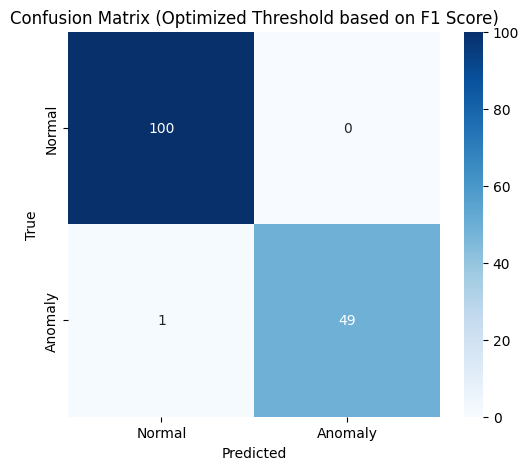

 ROC AUC Score (Optimized Threshold): 1.0000


In [29]:
# 최적 임계값으로 예측
y_pred_optimized = (mse > best_threshold).astype(int)
print("\n Classification Report (Optimized Threshold based on F1 Score):")
print(classification_report(y_test, y_pred_optimized, target_names=["Normal", "Anomaly"]))

print(" Confusion Matrix (Optimized Threshold based on F1 Score):")
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Confusion Matrix (Optimized Threshold based on F1 Score)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

roc_auc_optimized = roc_auc_score(y_test, mse) # MSE 기반 ROC AUC는 임계값 변경에 영향 없음
print(f" ROC AUC Score (Optimized Threshold): {roc_auc_optimized:.4f}")

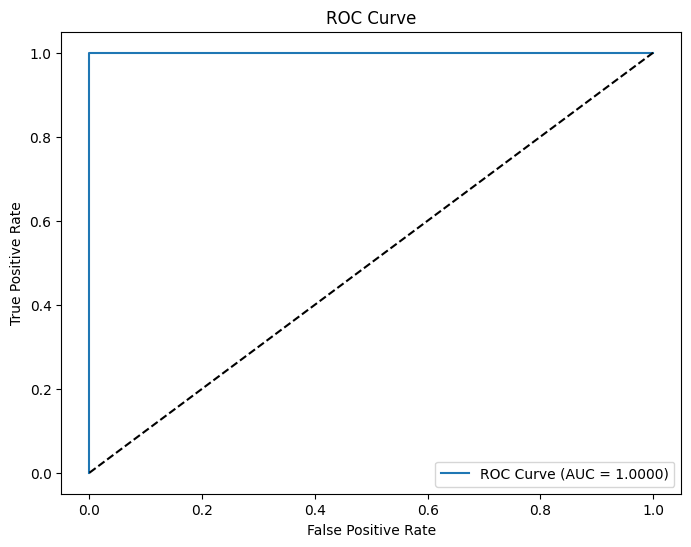

In [30]:
# 10. ROC 커브 시각화
fpr, tpr, _ = roc_curve(y_test, mse)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

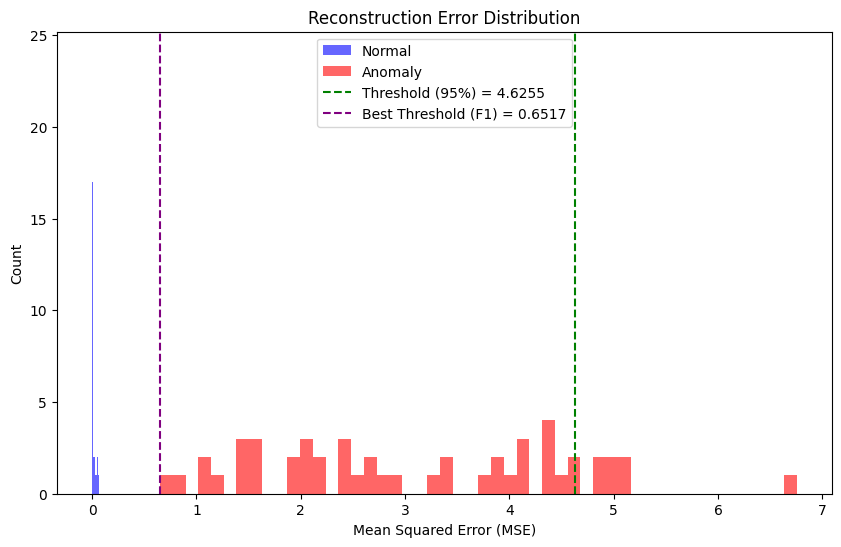

In [31]:
# 11. 시각화: 재구성 오차 분포
plt.figure(figsize=(10, 6))
plt.hist(mse[y_test == 0], bins=50, alpha=0.6, label="Normal", color='blue')
plt.hist(mse[y_test == 1], bins=50, alpha=0.6, label="Anomaly", color='red')
plt.axvline(threshold, color='green', linestyle='--', label=f'Threshold ({threshold_percentile}%) = {threshold:.4f}')
plt.axvline(best_threshold, color='purple', linestyle='--', label=f'Best Threshold (F1) = {best_threshold:.4f}')
plt.title("Reconstruction Error Distribution")
plt.xlabel("Mean Squared Error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.show()

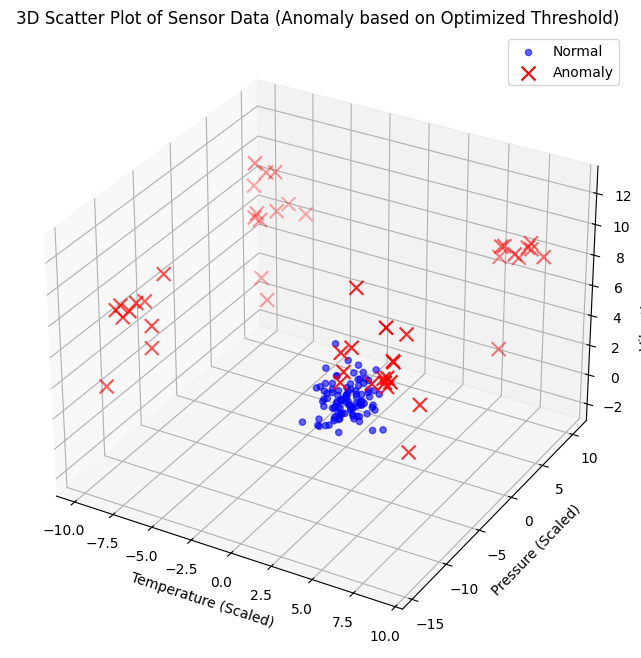

In [32]:
# 12. 시각화: 3D 산점도
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test_scaled[y_test == 0, 0], X_test_scaled[y_test == 0, 1], X_test_scaled[y_test == 0, 2],
           c='blue', label='Normal', alpha=0.6)
ax.scatter(X_test_scaled[y_pred_optimized == 1, 0], X_test_scaled[y_pred_optimized == 1, 1], X_test_scaled[y_pred_optimized == 1, 2],
           c='red', label='Anomaly', marker='x', s=100)
ax.set_xlabel("Temperature (Scaled)")
ax.set_ylabel("Pressure (Scaled)")
ax.set_zlabel("Vibration (Scaled)")
plt.title("3D Scatter Plot of Sensor Data (Anomaly based on Optimized Threshold)")
plt.legend()
plt.show()

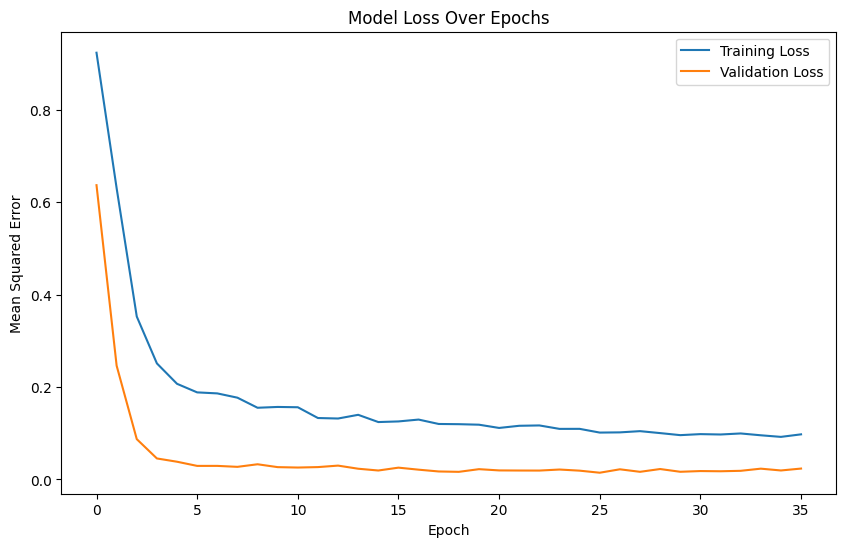

In [33]:
# 13. 학습 손실 시각화
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

In [34]:
# 14. 단일 테스트 데이터 예측
# 예시 데이터: 온도=25.0, 압력=100.0, 진동=0.5
# 필요 시 아래 값을 원하는 데이터로 변경하세요
test_sample = np.array([[25.0, 100.0, 0.5]])
test_sample_scaled = scaler.transform(test_sample)
test_sample_pred = autoencoder.predict(test_sample_scaled, verbose=0)
test_sample_mse = np.mean(np.square(test_sample_scaled - test_sample_pred))
is_anomaly = test_sample_mse > best_threshold # 최적 임계값 사용
print("\n🔍 단일 데이터 예측 결과 (Optimized Threshold):")
print(f"입력 데이터: 온도={test_sample[0, 0]}, 압력={test_sample[0, 1]}, 진동={test_sample[0, 2]}")
print(f"재구성 오차 (MSE): {test_sample_mse:.4f}")
print(f"결과: {'불량 (Anomaly)' if is_anomaly else '정상 (Normal)'}")


🔍 단일 데이터 예측 결과 (Optimized Threshold):
입력 데이터: 온도=25.0, 압력=100.0, 진동=0.5
재구성 오차 (MSE): 0.4038
결과: 정상 (Normal)
